<h1> Hill Climbing Algorithm </h1>

current = initial

while True:

    neighbors = generate(current)

    best = best neighbor

    if best is better:
        current = best

    else:
        break

return current

The main problem of Hill Climbing </br>
**Local Optimum** </br>
Plateau</br>
Ridge

Current Solution

      ↓

Generate Neighbors

      ↓

Find Best Neighbor

      ↓

If Better:
    Move

Else:
    Stop

In [1]:
from src.hill_climbing import (
    hill_climbing, 
    random_restart_hill_climbing,
)
import math
import matplotlib.pyplot as plt

<h3> Step 1: Classical / Local Search </h3>

In [2]:
def objective_function(x):
    return -(x - 3)**2 + 10

objective_function(3)

10

In [3]:
objective_function(0)

1

In [4]:
def get_neighbors(
    x,
    step_size=1
):

    return [
        x - step_size,
        x + step_size,
    ]
    
get_neighbors(5)

[4, 6]

Initial test

In [5]:
solution = hill_climbing(
    objective_function,
    initial_state=0,
    get_neighbors=get_neighbors,
)

solution

3

In [6]:
objective_function(solution)

10

We got the output 3 here because, when we started from element 0, the answer got better as we got closer to 3, to the point where 3 itself gave the answer 10, but then when the number 4 is tested, the answer drops, so the same answer 3 is returned.

The previous problem had only 1 peak, so the Hill algorithm worked, but the reason for the existence of Metaheuristic algorithms becomes clear precisely when the solution space becomes difficult.

<h3> Step 2: Demonstrating Local Optimum Problem </h3>

We create a function that has multiple vertices.

In [7]:
def multimodal_function(x):
    return math.sin(x) + 0.1*x

In [8]:
for x in [2,5,10,15,20]:
    print(
        x,
        multimodal_function(x)
    )

2 1.1092974268256817
5 -0.45892427466313845
10 0.4559788891106302
15 2.150287840157117
20 2.9129452507276277


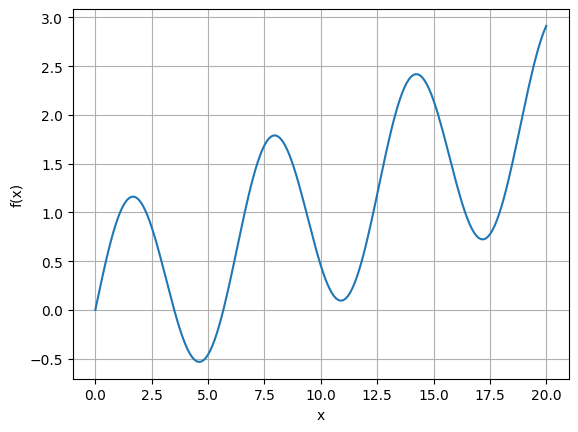

In [9]:
x_values = [
    x/10
    for x in range(0,201)
]

y_values = [
    multimodal_function(x)
    for x in x_values
]

plt.plot(
    x_values,
    y_values
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

plt.show()

In [10]:
starts = [
    1,
    5,
    10,
    15,
]

In [11]:
for start in starts:
    solution = hill_climbing(
        multimodal_function,
        start,
        get_neighbors,
    )

    print(
        "Start:",
        start,
        "Solution:",
        solution,
        "Value:",
        multimodal_function(solution)
    )

Start: 1 Solution: 2 Value: 1.1092974268256817
Start: 5 Solution: 8 Value: 1.7893582466233817
Start: 10 Solution: 8 Value: 1.7893582466233817
Start: 15 Solution: 14 Value: 2.3906073556948706


<h3> Step 3: Random Restart Hill Climbing </h3>

Random Start

      ↓

Hill Climbing

      ↓

Candidate Solution

      ↓

Repeat N times

      ↓

Best Solution

In [12]:
solution = random_restart_hill_climbing(
    multimodal_function,
    get_neighbors,
    (0,20),
    restarts=20,
)

print(solution)

print(
    multimodal_function(solution)
)

20.45722450818302
3.0450427460588223
